In [25]:
#importing required packages

#modelues for EDA steps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#modules for data cleaning and data analysis
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

#modules for model building
#algorithms for sampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

#baseline linear model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#modules for hyper parameter tuning
from sklearn.model_selection import GridSearchCV

#modules for model evaluation
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, accuracy_score, f1_score, r2_score
from sklearn.metrics import precision_recall_curve, roc_curve

#modules for avoiding warnings
import warnings
warnings.filterwarnings('ignore')

#setting backend for matplotlib
%matplotlib inline

from matplotlib.ticker import FuncFormatter

def thousands(x, pos):
    return f'{int(x/1000)}K'

In [2]:
data = pd.read_csv('Transactions.csv')

In [48]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['trans_hour'] = data['trans_date_trans_time'].dt.hour
data['trans_day'] = data['trans_date_trans_time'].dt.day_name()
data['trans_month'] = data['trans_date_trans_time'].dt.month
data['trans_year'] = data['trans_date_trans_time'].dt.year
data['trans_date'] = data['trans_date_trans_time'].dt.to_period('M').dt.to_timestamp()
data['dob'] = pd.to_datetime(data['dob'])
data['age'] = np.round((data['trans_date'] - data['dob']).dt.days / 365.25)
data['is_weekend'] = data['trans_day'].isin([5, 6])
data['afternoon'] = data['trans_hour'].between(12, 23)
data['late_night'] = data['trans_hour'].between(0, 5)

In [4]:
#  Transaction Counts in Time Window

# Sort by card and time
data = data.sort_values(['cc_num', 'trans_date'])

# Count transactions per card per hour
tx_count_hourly = (
    data.groupby(['cc_num', pd.Grouper(key='trans_date', freq='H')])
    .size()
    .reset_index(name='tx_count_1hr')
)

# Merge back to main data
data = pd.merge(data, tx_count_hourly, on=['cc_num', 'trans_date'], how='left')

In [5]:
# RFM Features (Recency, Frequency, Monetar
snapshot_date = data['trans_date'].max() + pd.Timedelta(days=1)

rfm = (
    data.groupby('cc_num')
    .agg({
        'trans_date': lambda x: (snapshot_date - x.max()).days,  # Recency
        'cc_num': 'count',                                       # Frequency
        'amt': 'sum'                                             # Monetary
    })
    .rename(columns={
        'trans_date': 'Recency',
        'cc_num': 'Frequency',
        'amt': 'Monetary'
    })
    .reset_index()
)

data = pd.merge(data, rfm, on='cc_num', how='left')

In [6]:
#Velocity Features (Transaction Rat
data = data.sort_values(['cc_num', 'trans_date'])
data['time_diff_sec'] = (
    data.groupby('cc_num')['trans_date']
    .diff().dt.total_seconds()
)

velocity = (
    data.groupby('cc_num')['time_diff_sec']
    .mean()
    .reset_index(name='avg_tx_interval_sec')
)

data = pd.merge(data, velocity, on='cc_num', how='left')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 41 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   trans_date_trans_time   1296675 non-null  datetime64[ns]
 1   cc_num                  1296675 non-null  int64         
 2   merchant                1296675 non-null  object        
 3   category                1296675 non-null  object        
 4   amt                     1296675 non-null  float64       
 5   street                  1296675 non-null  object        
 6   city                    1296675 non-null  object        
 7   state                   1296675 non-null  object        
 8   zip                     1296675 non-null  int64         
 9   lat                     1296675 non-null  float64       
 10  long                    1296675 non-null  float64       
 11  city_pop                1296675 non-null  int64         
 12  job           

In [7]:
#let us look at the number of unique values in the dataset
data.nunique()

trans_date_trans_time     1274791
cc_num                        983
merchant                      693
category                       14
amt                         52464
street                        983
city                          894
state                          51
zip                           970
lat                           968
long                          969
city_pop                      879
job                           494
dob                           968
trans_num                 1296675
merch_lat                 1247805
merch_long                1275745
is_fraud                        2
is_holiday                      2
is_5multiple                    2
is_lt2                          2
is_near2500                     2
is_whole_num                    2
is_595ending                    2
is_high_risk_merch_cat          2
dist_merch2cust             14454
trans_hour                     24
trans_day                       7
trans_month                    12
trans_year    

 splitting 'trans_date_trans_time' column, we will now separate the column into hour, day, and Month-year,to get more information from the column and concate these new columns to our original dataframe

In [9]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud', 'is_holiday',
       'is_5multiple', 'is_lt2', 'is_near2500', 'is_whole_num', 'is_595ending',
       'is_high_risk_merch_cat', 'dist_merch2cust', 'trans_hour', 'trans_day',
       'trans_month', 'trans_year', 'trans_date', 'age', 'is_weekend',
       'afternoon', 'late_night', 'tx_count_1hr', 'Recency', 'Frequency',
       'Monetary', 'time_diff_sec', 'avg_tx_interval_sec'],
      dtype='object')

In [12]:
data.isnull().sum()

trans_date_trans_time       0
cc_num                      0
merchant                    0
category                    0
amt                         0
street                      0
city                        0
state                       0
zip                         0
lat                         0
long                        0
city_pop                    0
job                         0
dob                         0
trans_num                   0
merch_lat                   0
merch_long                  0
is_fraud                    0
is_holiday                  0
is_5multiple                0
is_lt2                      0
is_near2500                 0
is_whole_num                0
is_595ending                0
is_high_risk_merch_cat      0
dist_merch2cust             0
trans_hour                  0
trans_day                   0
trans_month                 0
trans_year                  0
trans_date                  0
age                         0
is_weekend                  0
afternoon 

In [14]:
data.duplicated().sum()

0

In [15]:
round((data.is_fraud.value_counts(normalize=True))*100,1)

is_fraud
0    99.4
1     0.6
Name: proportion, dtype: float64

The above output indicates that this is an imbalanced dataset and there is a need to balance the data, in order to not produce any biases in the model.

# Exploring 'amt' data

In [16]:
#looking at distribution of amount
pd.concat(
    [data['amt'].describe(percentiles = [0.25,0.5,0.75,0.95,0.999]).reset_index().rename(columns={'index': 'Row Type', 'amt':'Overall Amt Distribution'}),
     data.loc[data['is_fraud']==0,['amt']].describe(percentiles = [0.25,0.5,0.75,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Non-Fraud Amt Distribution'}),
     data.loc[data['is_fraud']==1,['amt']].describe(percentiles = [0.25,0.5,0.75,0.95,0.999]).reset_index(drop = 1).rename(columns={'amt':'Fraud Amt Distribution'})], axis=1)

,Row Type,Overall Amt Distribution,Non-Fraud Amt Distribution,Fraud Amt Distribution
0,count,1.296675e+06,1.289169e+06,7506.000000
1,mean,6.906243e+01,6.766711e+01,308.710584
2,std,1.552509e+02,1.540080e+02,179.897128
3,min,1.000000e+00,1.000000e+00,1.060000
4,25%,9.650000e+00,9.610000e+00,228.605000
5,50%,4.752000e+01,4.728000e+01,338.680000
6,75%,8.314000e+01,8.254000e+01,450.437500
7,95%,1.963100e+02,1.899000e+02,541.992500
8,99.9%,1.499254e+03,1.503696e+03,645.519200
9,max,2.894890e+04,2.894890e+04,688.020000


- The mean of the 'non-fraud amt distribution' is far less than the 'fraud amt distribution'.
- This means that in a given set of transaction with balanced number of fraud and non-fraud data points, the mean transaction amount of fraud amt is very high. This implies that the amount lost in a fraud trnasaction is very high

In [25]:
data['trans_date'].nunique

<bound method IndexOpsMixin.nunique of 0         2019-01-01
1         2019-01-01
2         2019-01-01
3         2019-01-01
4         2019-01-01
             ...    
1296670   2020-06-01
1296671   2020-06-01
1296672   2020-06-01
1296673   2020-06-01
1296674   2020-06-01
Name: trans_date, Length: 1296675, dtype: datetime64[ns]>

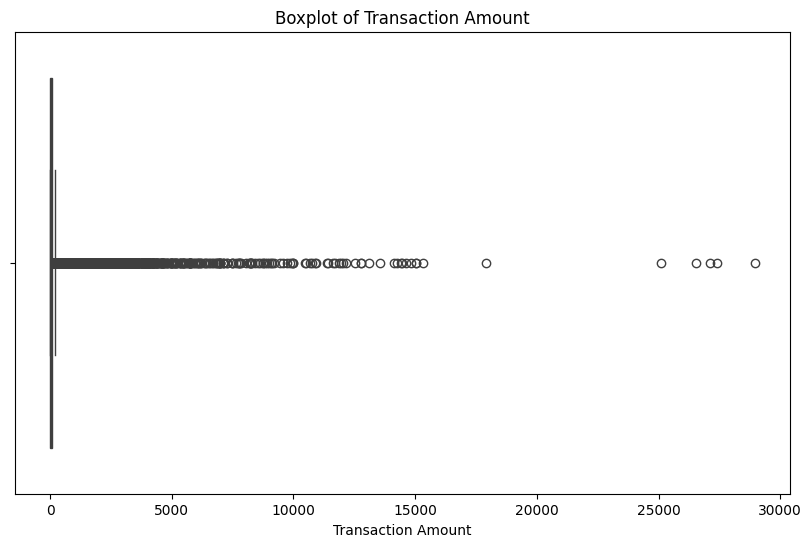

In [26]:
# Boxplot of 'amt'
plt.figure(figsize=(10, 6))
sns.boxplot(x=data.amt)
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.show()

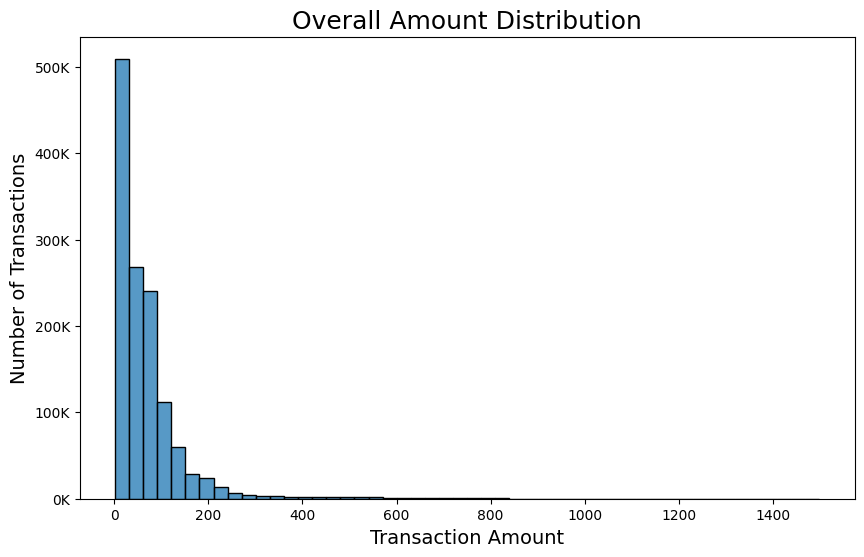

In [38]:

# Histogram of all transactions ≤ 1500
plt.figure(figsize=(10, 6))
sns.histplot(data[data.amt <= 1500].amt, bins=50)
plt.title('Overall Amount Distribution', fontsize=18)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))

plt.show()

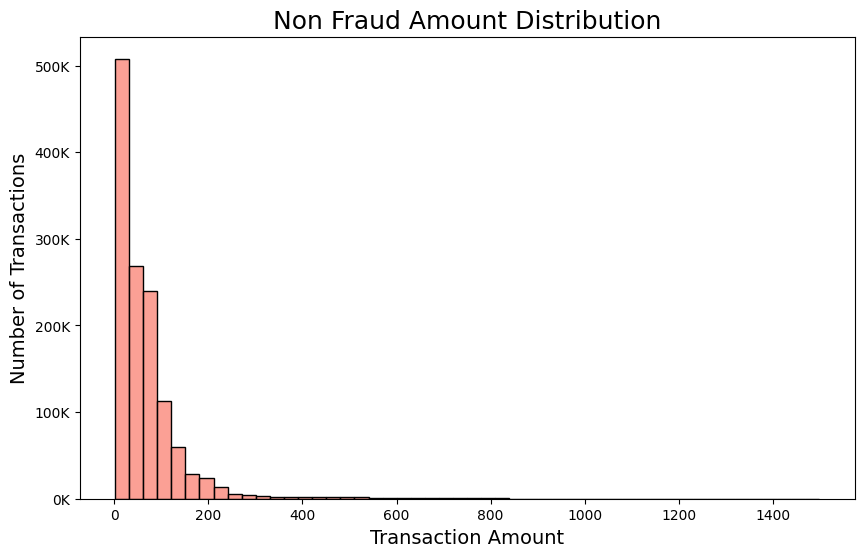

In [41]:
# Histogram of non-fraud transactions ≤ 1500
plt.figure(figsize=(10, 6))
sns.histplot(data[(data.is_fraud == 0) & (data.amt <= 1500)].amt, bins=50, color='salmon')
plt.title('Non Fraud Amount Distribution', fontsize=18)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
plt.show()


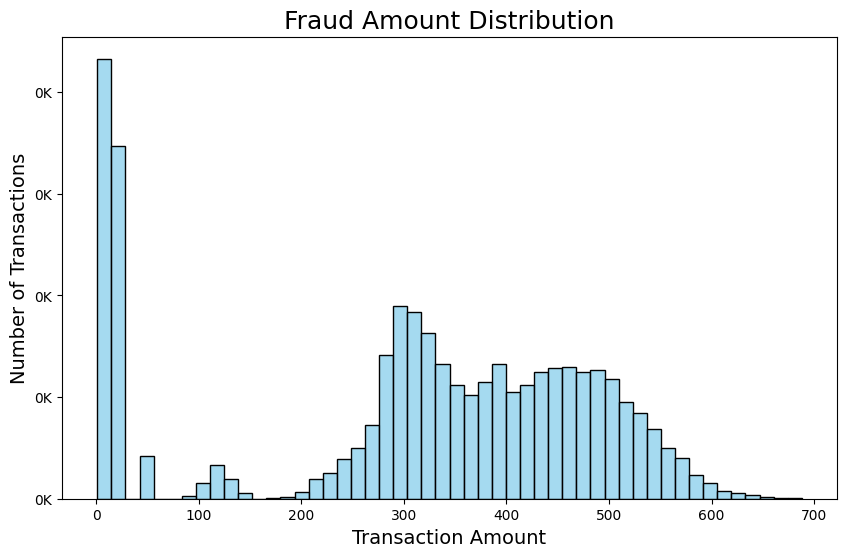

In [42]:
# Histogram of fraud transactions ≤ 1500
plt.figure(figsize=(10, 6))
sns.histplot(data[(data.is_fraud == 1) & (data.amt <= 1500)].amt, bins=50, color='skyblue')
plt.title('Fraud Amount Distribution', fontsize=18)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
plt.show()

# Observation ('amt' Feature):
- From the above plots, it can be noted that the 'amt' feature has a lot of outliers. This means that, the variance in the feature is huge.
- The distribution of the overall amount and the non fraud amount are similar with similar means.However, the mean of the fraud amount plot seems more than that of the other distributions.
- Also, the skewness in the data can be clearly seen.
# Inference
- From the above plot, though the mean of the fraud amount seems to be more than that of the non fraud or the overall amount, it can be observed that the fraud amount is evenly distributed and often records low amount value as compared to the other distributions.
- From this, it can be observed that the fraud amount transaction often happens in small amount, often aroung 200 and at times in the range of 200 to 400.
- Therefore, the transactions in which small amount is involved can be monitored more closely in order to detect and prevent credit card fraud

In [30]:
data.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'street', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud', 'is_holiday', 'is_5multiple', 'is_lt2',
       'is_near2500', 'is_whole_num', 'is_595ending', 'is_high_risk_merch_cat',
       'dist_merch2cust', 'trans_hour', 'trans_day', 'trans_date', 'age'],
      dtype='object')

# Exploring 'time' data

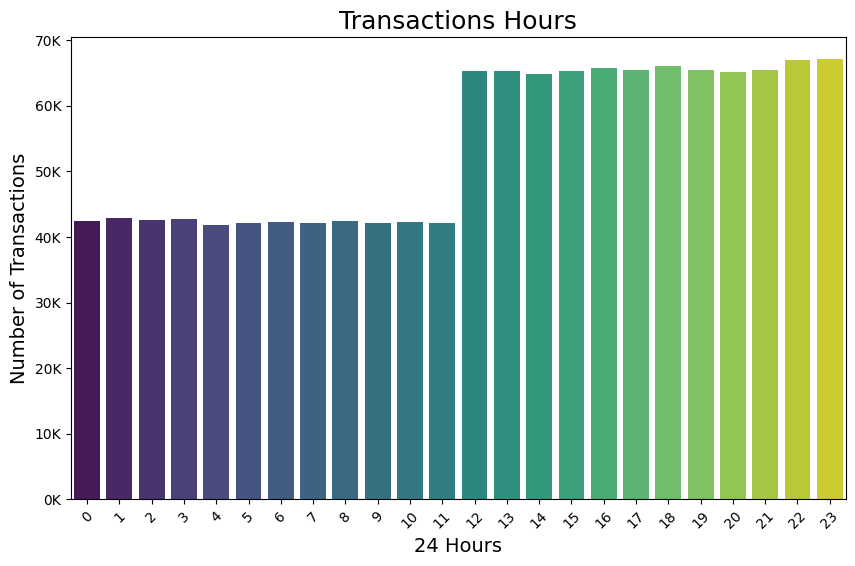

In [46]:
# Plotting 'trans_hour'
plt.figure(figsize=(10, 6))
sns.countplot(x=data.trans_hour, palette='viridis')
plt.xticks(rotation=45)
plt.title('Transactions Hours', fontsize=18)
plt.xlabel('24 Hours', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))

plt.show()

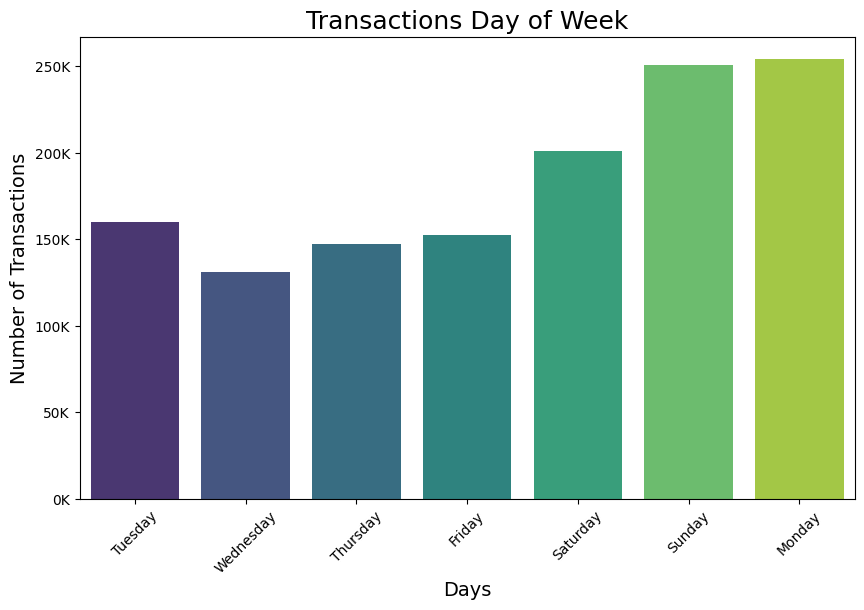

In [49]:
# Plotting 'trans_day'
plt.figure(figsize=(10, 6))
sns.countplot(x=data.trans_day, palette='viridis')
plt.xticks(rotation=45)
plt.title('Transactions Day of Week', fontsize=18)
plt.xlabel('Days', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
plt.show()

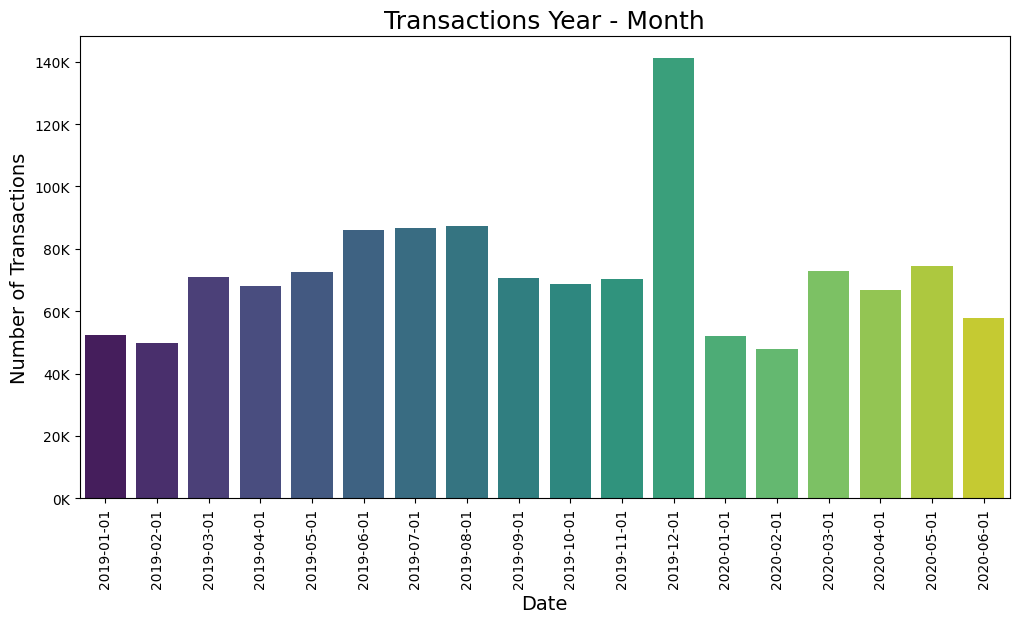

In [51]:
# Plotting 'trans_date'
plt.figure(figsize=(12, 6))
sns.countplot(x=data.trans_date, palette='viridis')
plt.xticks(rotation=90)
plt.title('Transactions Year - Month', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Transactions',fontsize=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands))
plt.show()

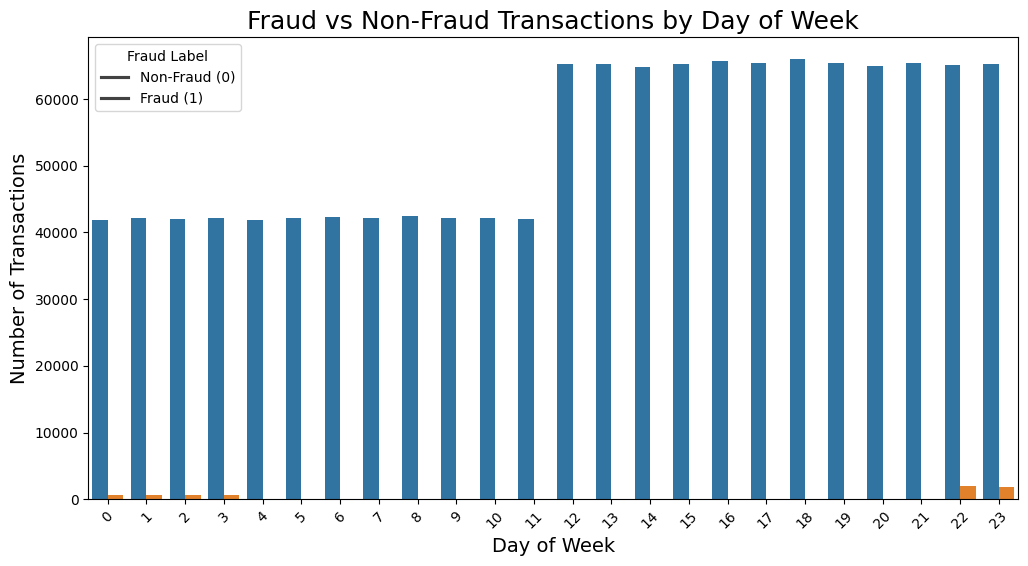

In [53]:
day_fraud_counts = data.groupby(['trans_hour', 'is_fraud']).size().reset_index(name='count')

# Step 2: Plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=day_fraud_counts, x='trans_hour', y='count', hue='is_fraud')

# Step 3: Customize labels
plt.title('Fraud vs Non-Fraud Transactions by Day of Week', fontsize=18)
plt.xlabel('Day of Week', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Fraud Label', labels=['Non-Fraud (0)', 'Fraud (1)'])

plt.show()


In [34]:
#year_month vs number of transactions
data_timeline01 = data.groupby(data['trans_date'])[['trans_num','cc_num']].nunique().reset_index()
data_timeline01.columns = ['year_month','num_of_transactions','customers']
data_timeline01

,year_month,num_of_transactions,customers
0,2019-01-01,52525,913
1,2019-02-01,49866,918
2,2019-03-01,70939,916
3,2019-04-01,68078,913
4,2019-05-01,72532,910
5,2019-06-01,86064,908
6,2019-07-01,86596,910
7,2019-08-01,87359,911
8,2019-09-01,70652,913
9,2019-10-01,68758,912


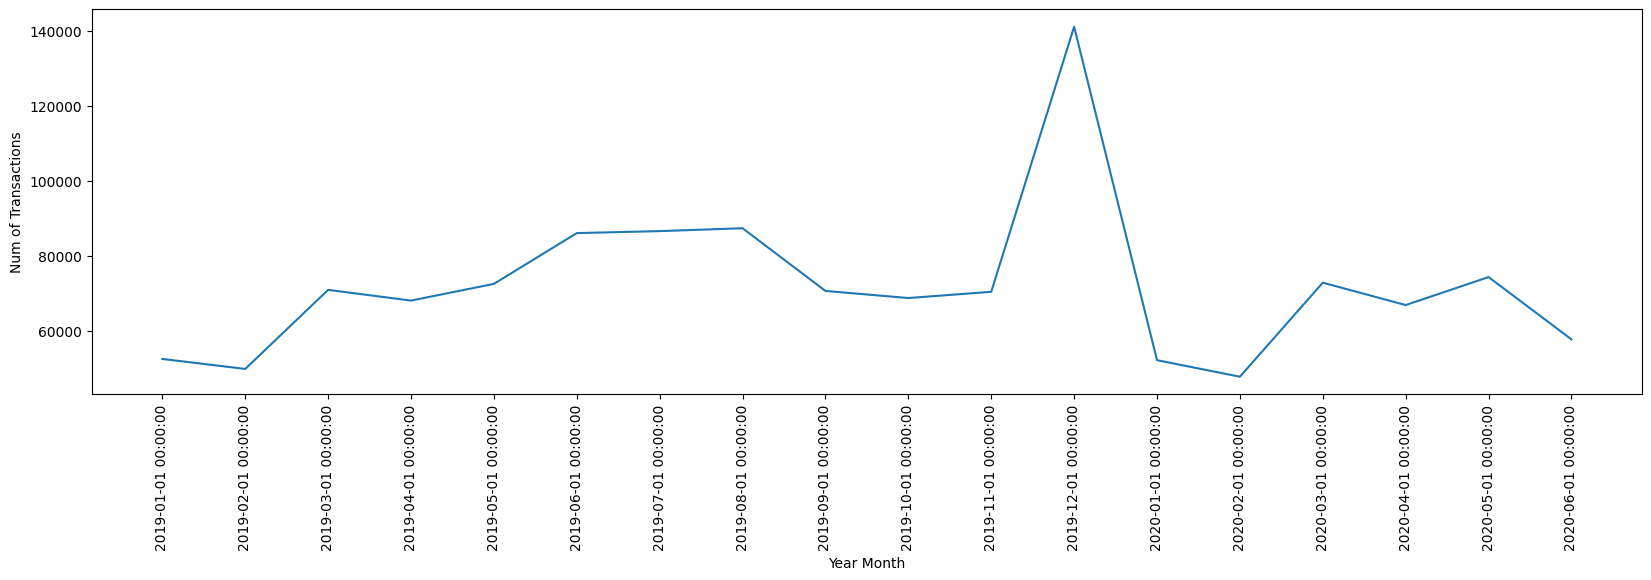

In [35]:
x = np.arange(0,len(data_timeline01),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,data_timeline01['num_of_transactions'])
ax.set_xticks(x)
ax.set_xticklabels(data_timeline01['year_month'])
plt.xticks(rotation=90)

ax.set_xlabel('Year Month')
ax.set_ylabel('Num of Transactions')
plt.show()

In [36]:
data_fraud_transactions = data[data['is_fraud']==1]

data_timeline02 = data_fraud_transactions.groupby(data_fraud_transactions['trans_date'])[['trans_num','cc_num']].nunique().reset_index()
data_timeline02.columns = ['year_month','num_of_fraud_transactions','fraud_customers']
data_timeline02

,year_month,num_of_fraud_transactions,fraud_customers
0,2019-01-01,506,50
1,2019-02-01,517,53
2,2019-03-01,494,49
3,2019-04-01,376,41
4,2019-05-01,408,42
5,2019-06-01,354,35
6,2019-07-01,331,36
7,2019-08-01,382,39
8,2019-09-01,418,44
9,2019-10-01,454,50


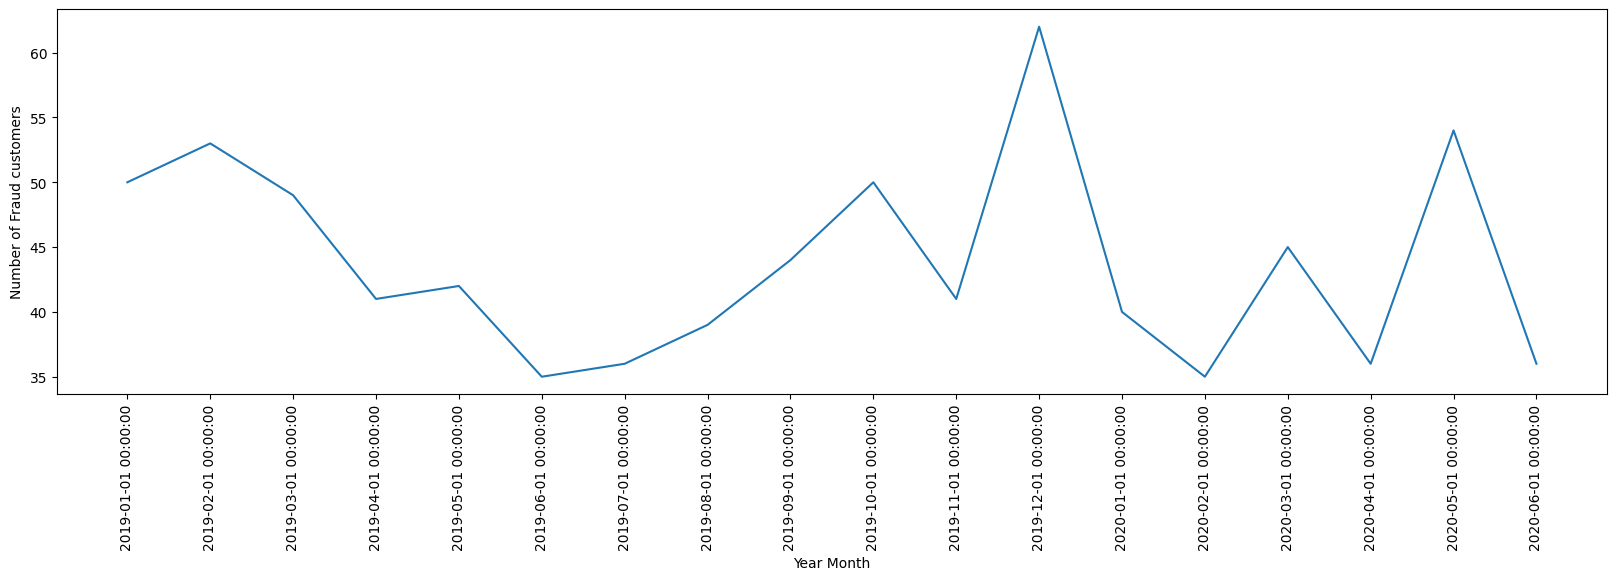

In [37]:
x = np.arange(0,len(data_timeline02),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,data_timeline02['fraud_customers'])
ax.set_xticks(x)
ax.set_xticklabels(data_timeline02['year_month'])
plt.xticks(rotation=90)

ax.set_xlabel('Year Month')
ax.set_ylabel('Number of Fraud customers')
plt.show()

# Observation (Time data):
- From the above visualizations it can be deduced that, the most number of transactions happened in the afternoon times of the day, i.e., after 12 pm in the afternoon.
- Also, most of the transactions according to the 'trans_week' data have happened during 'sunday' and 'monday' weekdays of the week.
- Moreover, according to the 'trans_date' data, most transactions have happened in the January, February, October, December months of 2019 and in the May month of 2020.
- Also, it can be noted that the number of fraud customers and the number of fraud transaction have increased in the time of December, which again is the holiday season.
# Inference:
- It can be observed that since most of the transaction happen after the noon hour of the day, the surveilance can be increased upon the transactions after 12pm in the day in order to reduce fraudulent transactions.
- In the holiday seasons like the 12th month of december, the number of transactions increase, such times can be monitored closely in order to reduce fraudulent transactions.
- Also, in the holiday season most people tend to go for shopping and other recreational and cultural activities during which people might be using their credit cards for various purposes. And hence, merchants in such a domain can be checked and educated about the fradulent practices happening

# Exploring Age data

In [38]:
#let us first bin the age feature
for i in range(len(data.age)):
  if data.age[i] <= 30:
    data.age[i] = '< 30'
  elif data.age[i] > 30 and data.age[i] <= 45:
    data.age[i] = '30-45'
  elif data.age[i] > 45 and data.age[i] <= 60:
    data.age[i] = '46-60'
  elif data.age[i] > 60 and data.age[i] <= 75:
    data.age[i] = '61-75'
  else:
    data.age[i] = '> 75'

data.age.head()

0    30-45
1    30-45
2    46-60
3    46-60
4    30-45
Name: age, dtype: object

In [39]:
data.head()

,cc_num,merchant,category,amt,street,city,state,zip,lat,long,...,is_lt2,is_near2500,is_whole_num,is_595ending,is_high_risk_merch_cat,dist_merch2cust,trans_hour,trans_day,trans_date,age
0,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,...,False,False,False,False,True,78.60,0,Tuesday,2019-01-01,30-45
1,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,...,False,False,False,False,True,30.21,0,Tuesday,2019-01-01,30-45
2,38859492057661,Lind-Buckridge,entertainment,220.11,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,...,False,False,False,False,False,108.21,0,Tuesday,2019-01-01,46-60
3,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,...,False,False,True,False,False,95.67,0,Tuesday,2019-01-01,46-60
4,375534208663984,Keeling-Crist,misc_pos,41.96,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,...,False,False,False,False,False,77.56,0,Tuesday,2019-01-01,30-45


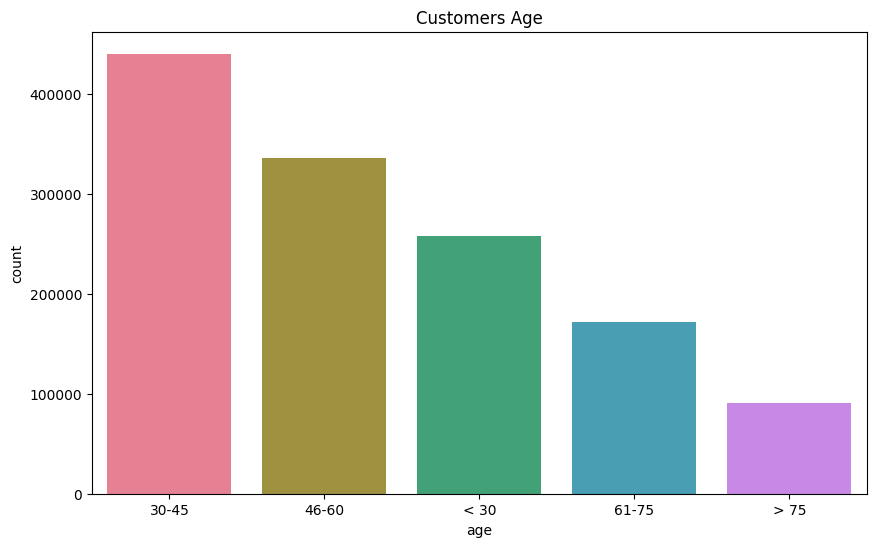

In [40]:
#plotting the age feature in the data
# Plotting 'trans_hour'
plt.figure(figsize=(10, 6))
sns.countplot(x=data.age, palette='husl')
plt.xticks(rotation=0)
plt.title('Customers Age')
plt.show()

In [41]:
#constructing the age-transaction count distribution
data_age = data[['age','trans_num']].groupby(['age']).count().reset_index()
data_age.columns = ['age', 'age_count']

#creating the age-fraud distribution
data_fraud_age = data[['age', 'trans_num', 'is_fraud']].groupby(['age','is_fraud']).count().reset_index()
data_fraud_age.columns = ['age', 'is_fraud', 'Transaction count']

data_fraud_age = data_fraud_age.merge(data_age[['age', 'age_count']], how='inner', on='age')

data_fraud_age['Transaction percentage'] = (data_fraud_age['Transaction count']/data_fraud_age['age_count'])*100
data_fraud_age

,age,is_fraud,Transaction count,age_count,Transaction percentage
0,30-45,0,438432,440301,99.575518
1,30-45,1,1869,440301,0.424482
2,46-60,0,334178,336330,99.360152
3,46-60,1,2152,336330,0.639848
4,61-75,0,170365,171469,99.356152
5,61-75,1,1104,171469,0.643848
6,< 30,0,256423,257962,99.403401
7,< 30,1,1539,257962,0.596599
8,> 75,0,89771,90613,99.070774
9,> 75,1,842,90613,0.929226


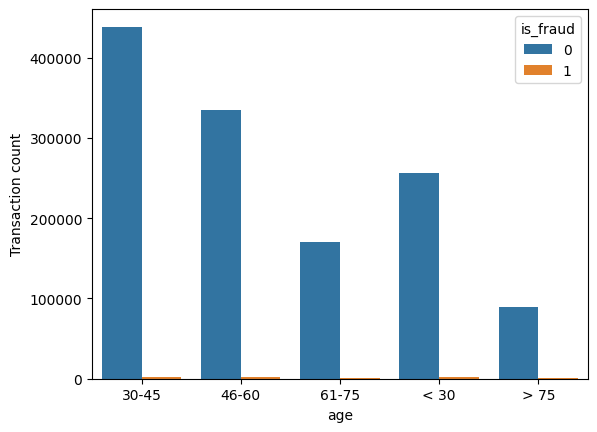

In [42]:
sns.barplot(data=data_fraud_age, y='Transaction count', x='age', hue='is_fraud')
plt.show()

# Observation (Age groups):
- from the above plots it can be observed that the most number of transactions in the datset have been done by the people in the 30-45 age group.
- Also, the 46-60 age group has done significant number of transactions.
- With respect to the total number of transaction made by a particular age group the people in the >75 age group are the most affected, wherein, about 1% transaction made by these people have been fraudulent.
# Inference:
- These are the people that are much prone to frauds and hence their transactions can be monitored with much more vigilance and they need to be educated regarding the frauds happening in order to reduce fraudulent transactions.
- The old age people might be targeted by fraudsters to take advantage of their lack of knowledge towards fina

# Exploring State data

In [43]:
data.state.nunique()

51

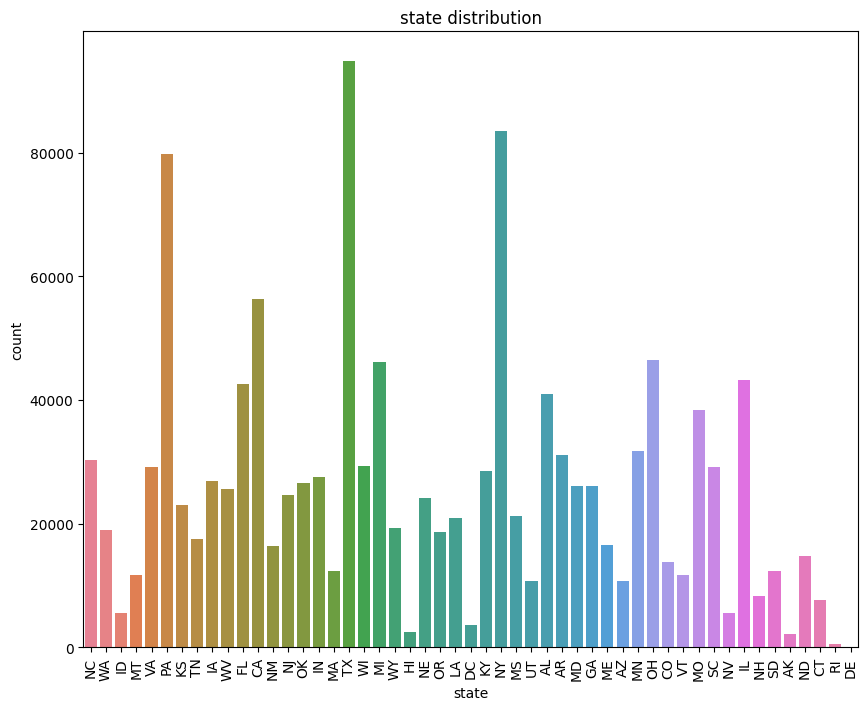

In [44]:
#plotting the age feature in the data
# Plotting 'trans_hour'
plt.figure(figsize=(10, 8))
sns.countplot(x=data.state, palette='husl')
plt.xticks(rotation=90)
plt.title('state distribution')
plt.show()

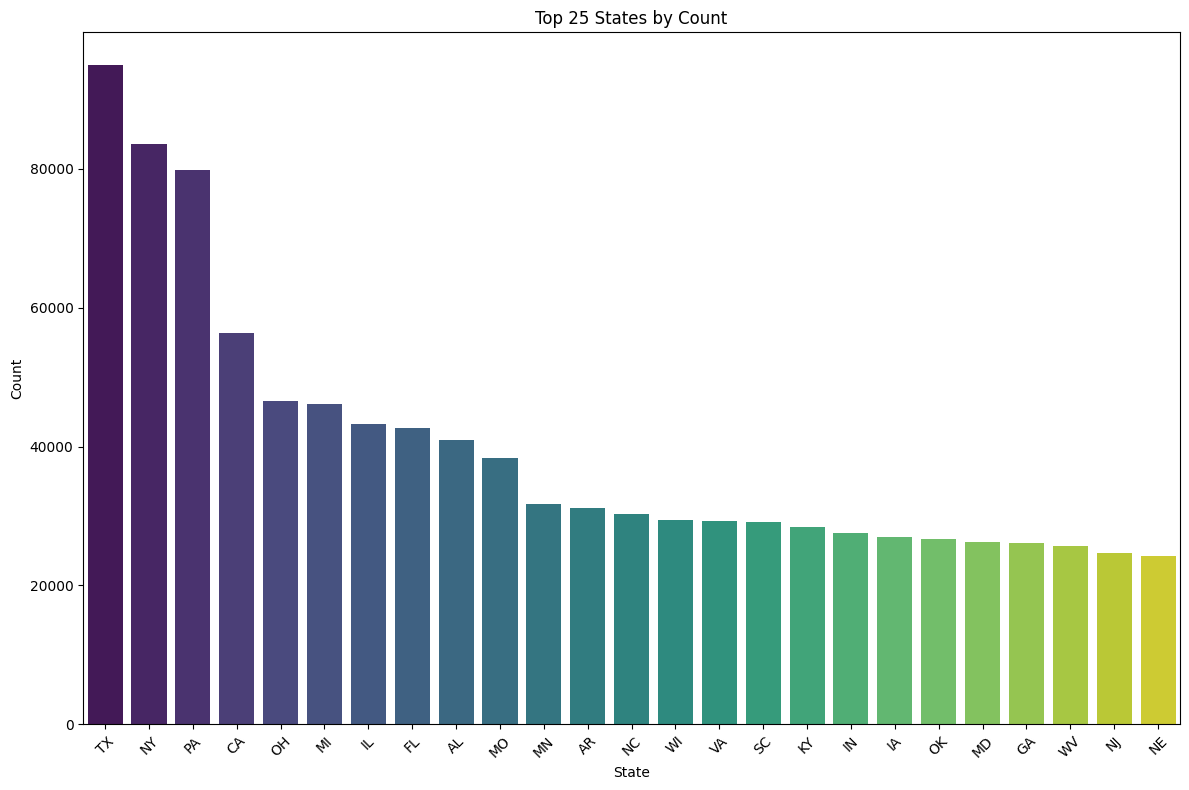

In [45]:
state_counts = data['state'].value_counts().nlargest(25)
plt.figure(figsize=(12, 8))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Top 25 States by Count')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [46]:
#constructing the state-transaction count distribution
data_state = data[['state','trans_num']].groupby(['state']).count().reset_index()
data_state.columns = ['state', 'state_count']

#creating the state-fraud distribution
data_fraud_state = data[['state', 'trans_num', 'is_fraud']].groupby(['state','is_fraud']).count().reset_index()
data_fraud_state.columns = ['state', 'is_fraud', 'Transaction count']

data_fraud_state = data_fraud_state.merge(data_state[['state', 'state_count']], how='inner', on='state')

data_fraud_state['Transaction percentage'] = (data_fraud_state['Transaction count']/data_fraud_state['state_count'])*100

#viewing the top 20 states with high fraudulent transactions
data_fraud_state[data_fraud_state['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(25)

,state,is_fraud,Transaction count,state_count,Transaction percentage
16,DE,1,9,9,100.000000
78,RI,1,15,550,2.727273
1,AK,1,36,2120,1.698113
66,NV,1,47,5607,0.838238
11,CO,1,113,13880,0.814121
74,OR,1,149,18597,0.801204
84,TN,1,140,17554,0.797539
58,NE,1,180,24168,0.744786
42,ME,1,119,16505,0.720994
60,NH,1,59,8278,0.712733


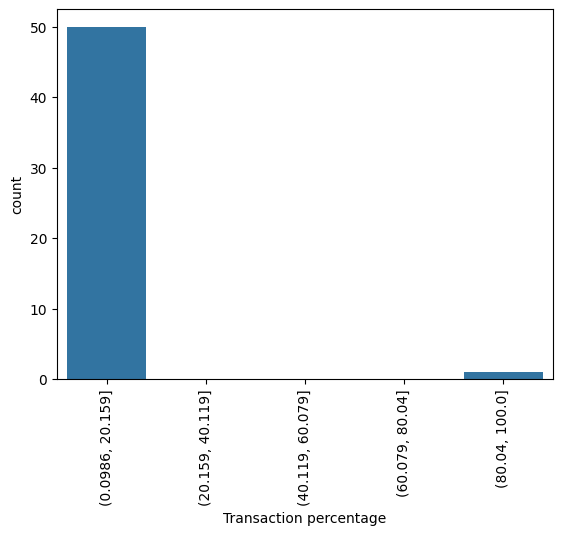

In [47]:
#plotting the fraudulent transactions percentage by binning
plot = sns.countplot(x=pd.cut(data_fraud_state[data_fraud_state.is_fraud == 1]['Transaction percentage'], bins = 5))
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)
plt.show()

In [48]:
#states with more than 75% fraudulent transactions
print('state with more than 75% fraudulent transactions:\n')
print(data_fraud_state.loc[(data_fraud_state.is_fraud == 1) & (data_fraud_state['Transaction percentage'] >= 75)].state)

state with more than 75% fraudulent transactions:

16    DE
Name: state, dtype: object


# Observation (State feature):
- The states 'PA', 'TX', 'NY' have the most amount of transactions noted in the given dataset.
- The next highest in the list are 'FL', 'CA', 'MI', 'AL', 'OH' and 'IL'.
- Majority of the transactions are happening in these states, and hence there is a high chance of fraudulent transaction happening in those states thourgh various methods including ATM and POS machine tamperings.
- In the top 25 states with high transaction volumes, it can be noted that all states have a fraudulent transaction of about 0.5%.
- 'DE' is the most fraudulent state.

# Inference:
- In view of the above observations, it can be concluded that in order to reduce the number of fraudulent transactions overall, it is necessary that the monitoring of transactions in areas where in the most number of transaction must be increased.
- Therefore, the people in these areas could be alerted about the fradulent practices and can be adviced to follow the best practices to reduce the number of credit card frauds.

# Exploring 'city' and 'zip' variables:

In [49]:
print('number of cities: ')
data.city.nunique()

number of cities: 


894

In [50]:
print('number of zip codes: ')
data.zip.nunique()

number of zip codes: 


970

In [51]:
high_trans_cities = data.city.value_counts().head(25).index.tolist()
high_trans_zips = data.zip.value_counts().head(25).index.tolist()
print('high frequencies cities: ', high_trans_cities)
print('high frequencies zip codes: ', high_trans_zips)

high frequencies cities:  ['Birmingham', 'San Antonio', 'Utica', 'Phoenix', 'Meridian', 'Thomas', 'Conway', 'Cleveland', 'Warren', 'Houston', 'Burbank', 'Naples', 'Arcadia', 'Indianapolis', 'Brandon', 'Fulton', 'Lahoma', 'Allentown', 'Lakeland', 'Dallas', 'Washington', 'Andrews', 'Detroit', 'Huntsville', 'Hudson']
high frequencies zip codes:  [73754, 34112, 48088, 82514, 49628, 15484, 85173, 29819, 38761, 5461, 44233, 4287, 72042, 16858, 28405, 26292, 12419, 80120, 6024, 98238, 64019, 36749, 66018, 72011, 7060]


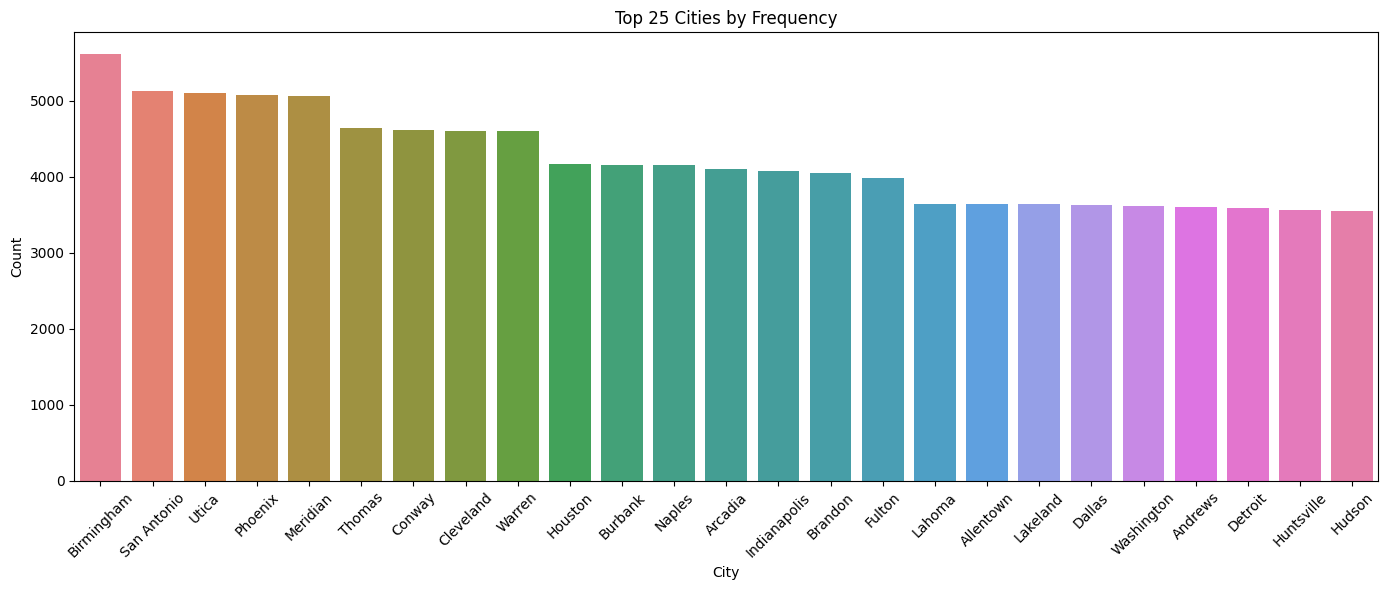

In [52]:
# Filter data for top cities
top_cities_data = data[data['city'].isin(high_trans_cities)]

# Plot top cities
plt.figure(figsize=(14, 6))
sns.countplot(data=top_cities_data, x='city', order=high_trans_cities, palette='husl')
plt.title('Top 25 Cities by Frequency')
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


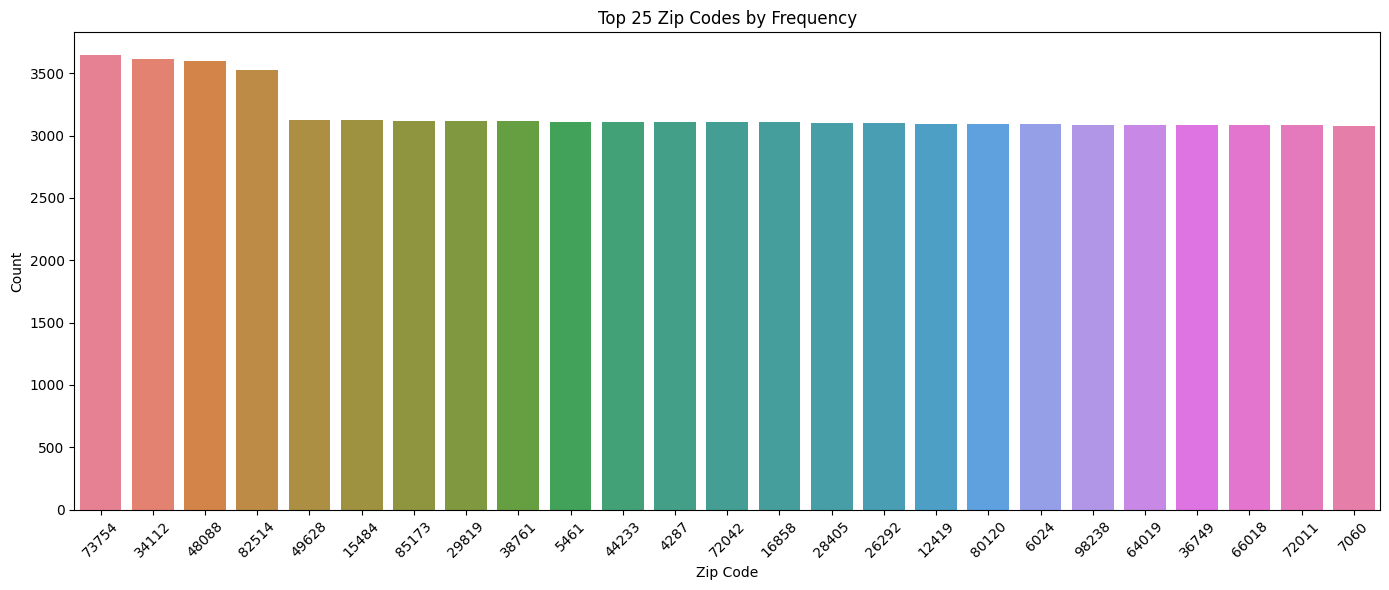

In [53]:
# Filter data for top zip codes
top_zips_data = data[data['zip'].isin(high_trans_zips)]

# Plot top zip codes
plt.figure(figsize=(14, 6))
sns.countplot(data=top_zips_data, x='zip', order=high_trans_zips, palette='husl')
plt.title('Top 25 Zip Codes by Frequency')
plt.xticks(rotation=45)
plt.xlabel('Zip Code')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [54]:
#constructing the city-transaction count distribution
data_city = data[['city','trans_num']].groupby(['city']).count().reset_index()
data_city.columns = ['city', 'city_count']

#creating the city-fraud distribution
data_fraud_city = data[['city', 'trans_num', 'is_fraud']].groupby(['city','is_fraud']).count().reset_index()
data_fraud_city.columns = ['city', 'is_fraud', 'Transaction count']

data_fraud_city = data_fraud_city.merge(data_city[['city', 'city_count']], how='inner', on='city')

data_fraud_city['Transaction percentage'] = (data_fraud_city['Transaction count']/data_fraud_city['city_count'])*100
#viewing the top 20 cities with high fraudulent transaction volumes
data_fraud_city[data_fraud_city['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(25)

,city,is_fraud,Transaction count,city_count,Transaction percentage
401,East China,1,9,9,100.0
1441,Walkertown,1,11,11,100.0
476,Freeport,1,9,9,100.0
483,Gaines,1,8,8,100.0
511,Granbury,1,12,12,100.0
1060,Orange Park,1,10,10,100.0
531,Greenport,1,10,10,100.0
101,Beacon,1,11,11,100.0
1444,Wappapello,1,8,8,100.0
989,Nicholson,1,9,9,100.0


In [55]:
#constructing the zip-transaction count distribution
data_zip = data[['zip','trans_num']].groupby(['zip']).count().reset_index()
data_zip.columns = ['zip', 'zip_count']

#creating the zip-fraud distribution
data_fraud_zip = data[['zip', 'trans_num', 'is_fraud']].groupby(['zip','is_fraud']).count().reset_index()
data_fraud_zip.columns = ['zip', 'is_fraud', 'Transaction count']

data_fraud_zip = data_fraud_zip.merge(data_zip[['zip', 'zip_count']], how='inner', on='zip')

data_fraud_zip['Transaction percentage'] = (data_fraud_zip['Transaction count']/data_fraud_zip['zip_count'])*100

#viewing the top 20 zip codes with high fraudulent transaction volumes
data_fraud_zip[data_fraud_zip['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,zip,is_fraud,Transaction count,zip_count,Transaction percentage
1363,77027,1,7,7,100.0
1315,75246,1,11,11,100.0
135,11944,1,10,10,100.0
1293,74108,1,10,10,100.0
130,11763,1,9,9,100.0
129,11747,1,15,15,100.0
527,32065,1,10,10,100.0
1064,61364,1,7,7,100.0
446,28412,1,9,9,100.0
1513,89109,1,8,8,100.0


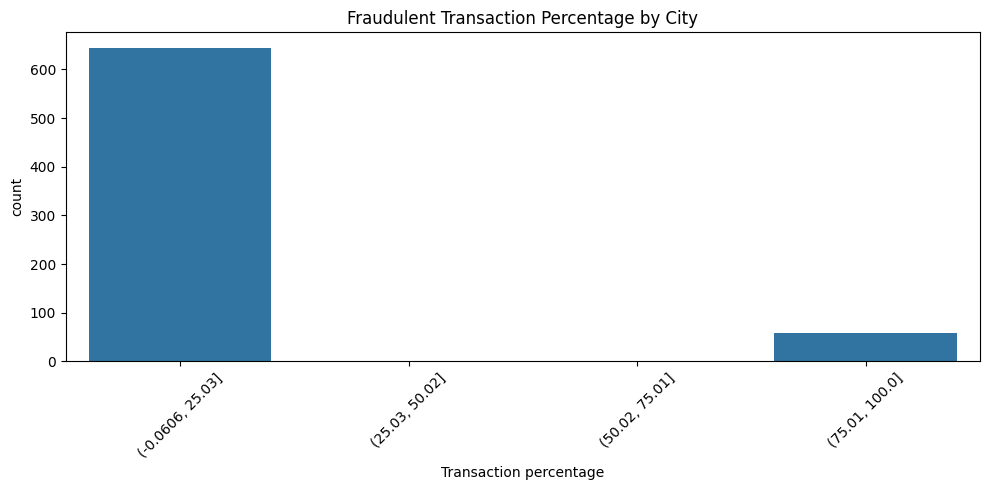

In [56]:
# City plot
plt.figure(figsize=(10, 5))
sns.countplot(x=pd.cut(data_fraud_city[data_fraud_city.is_fraud == 1]['Transaction percentage'], bins=4))
plt.title('Fraudulent Transaction Percentage by City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


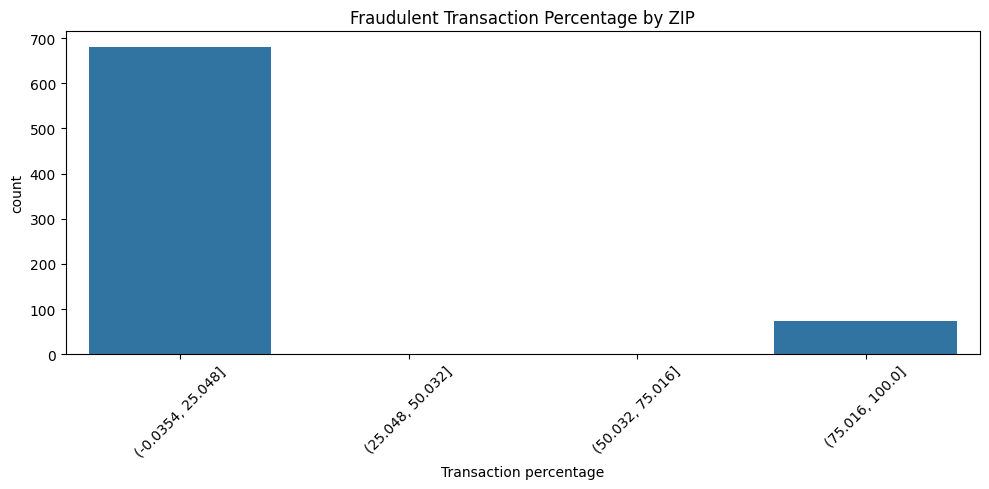

In [57]:
# ZIP plot
plt.figure(figsize=(10, 5))
sns.countplot(x=pd.cut(data_fraud_zip[data_fraud_zip.is_fraud == 1]['Transaction percentage'], bins=4))
plt.title('Fraudulent Transaction Percentage by ZIP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [58]:
#cities and zip codes with more fraudulent transactions
print('Cities with more than 75% fraudulent transactions:\n')
print(data_fraud_city.loc[(data_fraud_city.is_fraud == 1) & (data_fraud_city['Transaction percentage'] >= 75)].city.tolist())
print('\n\nZip codes with more than 75% fraudulent transactions:\n')
print(data_fraud_zip.loc[(data_fraud_zip.is_fraud == 1) & (data_fraud_zip['Transaction percentage'] >= 75)].zip.tolist())

Cities with more than 75% fraudulent transactions:

['Angwin', 'Ashland', 'Beacon', 'Brookfield', 'Bruce', 'Buellton', 'Byesville', 'Chattanooga', 'Clarion', 'Claypool', 'Clinton', 'Coulee Dam', 'Crouse', 'Downey', 'East China', 'Freeport', 'Gaines', 'Granbury', 'Greenport', 'Grenola', 'Hubbell', 'Irvington', 'Isanti', 'Kaktovik', 'Karns City', 'La Grande', 'Las Vegas', 'Lockhart', 'Madisonville', 'Marshall', 'Medford', 'Melville', 'Mineral', 'Morven', 'Moss Point', 'Mount Vernon', 'Mountain City', 'Nanuet', 'Nicholson', 'Noblesville', 'Norfolk', 'North East', 'Oakton', 'Orange Park', 'Phelps', 'Pleasant Hill', 'Queen Anne', 'Ridge Spring', 'Roland', 'Seattle', 'Streator', 'Vacaville', 'Walkertown', 'Wappapello', 'Wartburg', 'Waukau', 'West Frankfort', 'Winnsboro']


Zip codes with more than 75% fraudulent transactions:

[4032, 10018, 10533, 10553, 10954, 11747, 11763, 11944, 12207, 12508, 14532, 16041, 16214, 16428, 18446, 19947, 21657, 22124, 23117, 23523, 27051, 28033, 28119, 28412,

# Observation ('city' and 'zip' features):
- from the above plot the places with high transaction frequencies can be observed.
- it is common knowledge that these zip codes and cities are some of the busiest places in the world which justifies the transaction frequencies in these areas.
- about 50 zip codes and 70 cities have more than 75% fradulent transactions.
# Inference:
- The people in these area can be educated about the risks associated with using credit cards with respect to frauds.
- the monitoring of transactions can be increased in order to decrease the number of fraudulent transacions.

# Exploring the Job feature

In [59]:
data.job.nunique()

494

In [60]:
#fetching top 25 jobs with high transaction frequencies
high_trans_jobs = data.job.value_counts().head(25).index.tolist()
print(high_trans_jobs)

['Film/video editor', 'Exhibition designer', 'Naval architect', 'Surveyor, land/geomatics', 'Materials engineer', 'Designer, ceramics/pottery', 'Systems developer', 'IT trainer', 'Financial adviser', 'Environmental consultant', 'Chartered public finance accountant', 'Scientist, audiological', 'Chief Executive Officer', 'Copywriter, advertising', 'Comptroller', 'Sub', 'Podiatrist', 'Agricultural consultant', 'Paramedic', 'Magazine features editor', 'Historic buildings inspector/conservation officer', 'Librarian, public', 'Building surveyor', 'Musician', 'Water engineer']


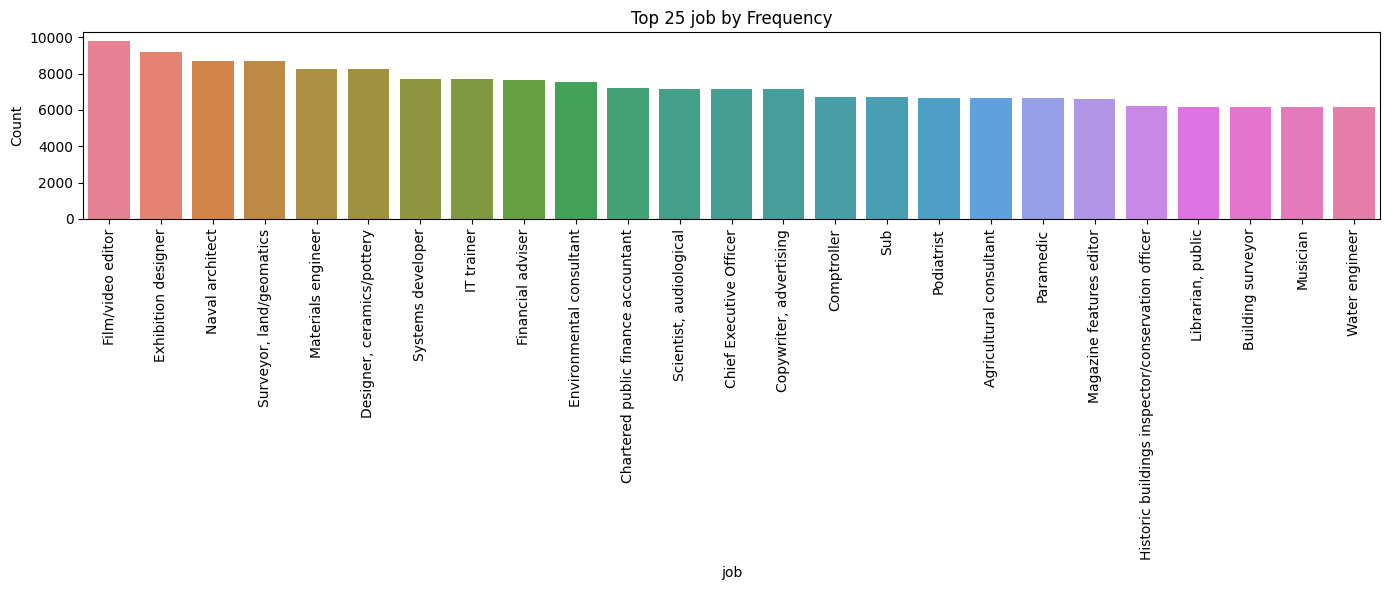

In [61]:
# Filter data for top zip codes
top_zips_data = data[data['job'].isin(high_trans_jobs)]

# Plot top zip codes
plt.figure(figsize=(14, 6))
sns.countplot(data=top_zips_data, x='job', order=high_trans_jobs, palette='husl')
plt.title('Top 25 job by Frequency')
plt.xticks(rotation=90)
plt.xlabel('job')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [62]:
#constructing the zip-transaction count distribution
data_job = data[['job','trans_num']].groupby(['job']).count().reset_index()
data_job.columns = ['job', 'job_count']

#creating the zip-fraud distribution
data_fraud_job = data[['job', 'trans_num', 'is_fraud']].groupby(['job','is_fraud']).count().reset_index()
data_fraud_job.columns = ['job', 'is_fraud', 'Transaction count']

data_fraud_job = data_fraud_job.merge(data_job[['job', 'job_count']], how='inner', on='job')

data_fraud_job['Transaction percentage'] = (data_fraud_job['Transaction count']/data_fraud_job['job_count'])*100

#viewing the top 20 jobs with high fraudulent transaction volumes
data_fraud_job[data_fraud_job['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(25)

,job,is_fraud,Transaction count,job_count,Transaction percentage
64,Armed forces technical officer,1,8,8,100.000000
318,"Engineer, site",1,12,12,100.000000
453,Information officer,1,8,8,100.000000
493,Legal secretary,1,12,12,100.000000
450,Industrial buyer,1,10,10,100.000000
111,Careers adviser,1,15,15,100.000000
421,Homeopath,1,11,11,100.000000
94,Broadcast journalist,1,9,9,100.000000
619,Personnel officer,1,12,12,100.000000
374,Forest/woodland manager,1,9,9,100.000000


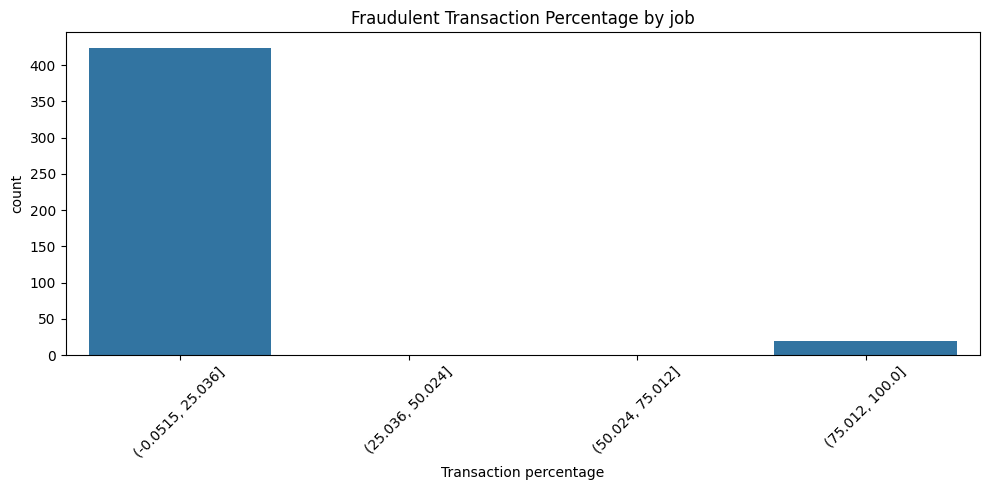

In [63]:
# ZIP plot
plt.figure(figsize=(10, 5))
sns.countplot(x=pd.cut(data_fraud_job[data_fraud_job.is_fraud == 1]['Transaction percentage'], bins = 4))
plt.title('Fraudulent Transaction Percentage by job')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [64]:
#job with more than one percent fraudulent transactions
data_fraud_job.loc[(data_fraud_job.is_fraud == 1) & (data_fraud_job['Transaction percentage'] >= 50)].job

2                  Accountant, chartered
39                Air traffic controller
64        Armed forces technical officer
94                  Broadcast journalist
111                      Careers adviser
198           Contracting civil engineer
218                               Dancer
318                       Engineer, site
374              Forest/woodland manager
421                            Homeopath
450                     Industrial buyer
453                  Information officer
493                      Legal secretary
619                    Personnel officer
758    Sales promotion account executive
787                          Ship broker
795                            Solicitor
898                   Veterinary surgeon
906                    Warehouse manager
Name: job, dtype: object

# Observation ('job' feature):
- The above are the jobs where in high transaction frequencies have been noted.
- In the above dataframe, the transactions containing the job feature value as-Armed forces technical officer; Engineer, site; Information officer; Legal secretary; Industrial buyer; Careers adviser; Homeopath; Broadcast journalist; Personnel officer; Forest/woodland manager; Sales promotion account executive; Air traffic controller; Contracting civil engineer; Ship broker; Solicitor;2 Accountant, chartered; Dancer; Warehouse manager; Veterinary surgeon have completely fraudulent transactions.
# Inference:
- The people in the jobs with high number of fraudulent transactions can be alerted about the credit card transaction frauds so that they can be more carefull while using their credit cards.
- the jobs roles in which almost all transactions are fraudulent might mean that there is some fault with the datapoint. That is, the person representing the specific job might be at fault since it is highly unlikely that all the transactions made by a person from a spceific job are fraudulent. Hence, doing some kind of background check upon the credit card user might help in this case.

# Exploring the 'category' feature:

In [65]:
data.category.value_counts(normalize=True)

category
gas_transport     0.101536
grocery_pos       0.095350
home              0.094947
shopping_pos      0.089978
kids_pets         0.087173
shopping_net      0.075225
entertainment     0.072504
food_dining       0.070535
personal_care     0.069993
health_fitness    0.066230
misc_pos          0.061430
misc_net          0.048807
grocery_net       0.035053
travel            0.031239
Name: proportion, dtype: float64

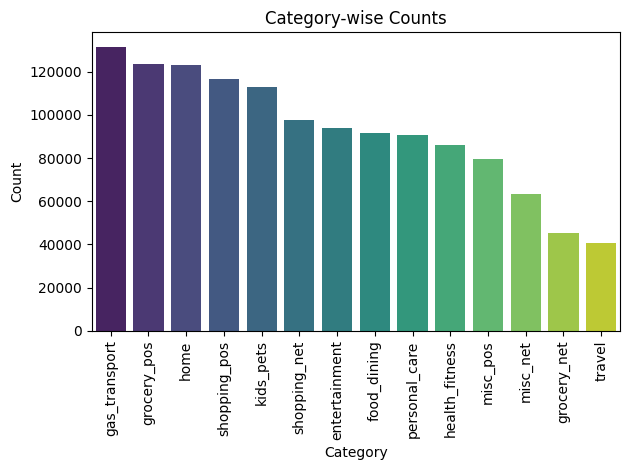

In [66]:
sorted_categories = data['category'].value_counts().index

# Create the plot
plot = sns.countplot(x='category', data=data, order=sorted_categories, palette='viridis')

# Customize labels and layout
plt.title('Category-wise Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()


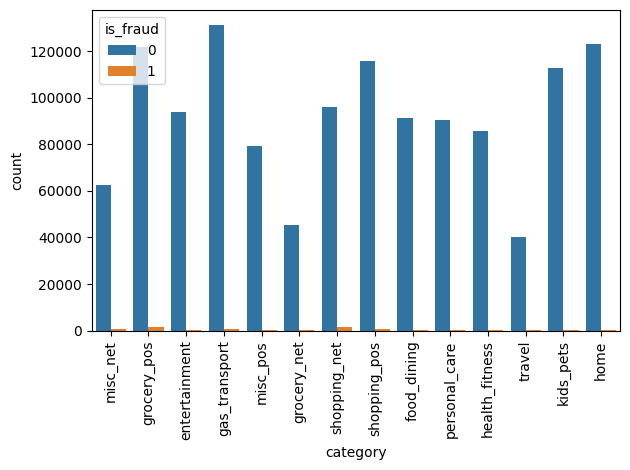

In [67]:
#let us see the number of fraudulent transaction in these categories
plot = sns.countplot(x='category', hue='is_fraud', data=data)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()


In [68]:
#constructing the category-transaction count distribution
data_category = data[['category','trans_num']].groupby(['category']).count().reset_index()
data_category.columns = ['category', 'category_count']

#creating the zip-fraud distribution
data_fraud_category = data[['category', 'trans_num', 'is_fraud']].groupby(['category','is_fraud']).count().reset_index()
data_fraud_category.columns = ['category', 'is_fraud', 'Transaction count']

data_fraud_category = data_fraud_category.merge(data_category[['category', 'category_count']], how='inner', on='category')

data_fraud_category['Transaction percentage'] = (data_fraud_category['Transaction count']/data_fraud_category['category_count'])*100

#viewing the top categories with high fraudulent transaction volumes
data_fraud_category[data_fraud_category['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False)

,category,is_fraud,Transaction count,category_count,Transaction percentage
23,shopping_net,1,1713,97543,1.756149
17,misc_net,1,915,63287,1.445795
9,grocery_pos,1,1743,123638,1.409761
25,shopping_pos,1,843,116672,0.722538
5,gas_transport,1,618,131659,0.469394
19,misc_pos,1,250,79655,0.313853
7,grocery_net,1,134,45452,0.294817
27,travel,1,116,40507,0.286370
1,entertainment,1,233,94014,0.247835
21,personal_care,1,220,90758,0.242403


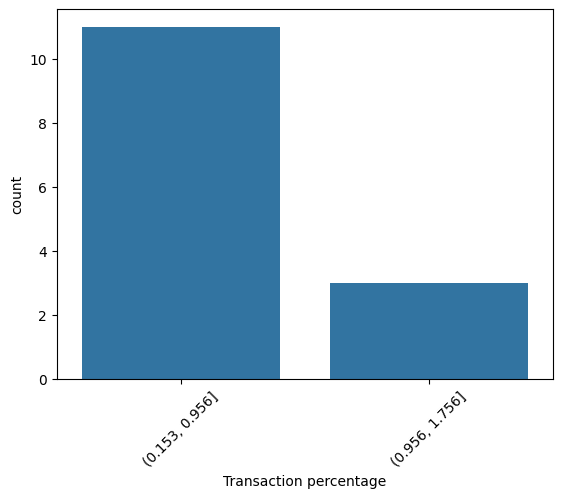

In [69]:
#plotting the fraudulent transactions percentage by binning
plot = sns.countplot(x=pd.cut(data_fraud_category[data_fraud_category.is_fraud == 1]['Transaction percentage'], bins = 2))
plot.set_xticklabels(plot.get_xticklabels(), rotation = 45)
plt.show()

In [70]:
#categories with more than one percent fraudulent transactions
data_fraud_category.loc[(data_fraud_category.is_fraud == 1) & (data_fraud_category['Transaction percentage'] >= 1)].category

9      grocery_pos
17        misc_net
23    shopping_net
Name: category, dtype: object

In [71]:
data_fraud_category.head()


,category,is_fraud,Transaction count,category_count,Transaction percentage
0,entertainment,0,93781,94014,99.752165
1,entertainment,1,233,94014,0.247835
2,food_dining,0,91310,91461,99.834902
3,food_dining,1,151,91461,0.165098
4,gas_transport,0,131041,131659,99.530606


# Observation ('category' feature):
- from the above plots and dataframes created, it can be observed that about 3 categories have more than 1% fraudulent transactions involved. These are - grocery_pos, misc_net, shopping_net.
- out these, the shopping_net category has the most number of fraudulent transactions.
# Inference:
- From the above observations, it can be inferred that, most of the fraudulent transactions are taking place in the shopping_net category. It is possible that the fruadsters have placed certain defective transaction equipments or other mechanisms which have increased the number of fraudulent transactions.
- therefore, the above mentioned categories can be checked thoroughly in order to reduce the fraud percentage.

# Exploring 'Merchant' Feature:

In [72]:
data.merchant.nunique()

693

In [73]:
high_trans_merchants = data.merchant.value_counts().head(25).index.tolist()
high_trans_merchants

['Kilback LLC',
 'Cormier LLC',
 'Schumm PLC',
 'Kuhn LLC',
 'Boyer PLC',
 'Dickinson Ltd',
 'Cummerata-Jones',
 'Kutch LLC',
 'Olson, Becker and Koch',
 'Stroman, Hudson and Erdman',
 'Rodriguez Group',
 'Erdman-Kertzmann',
 'Jenkins, Hauck and Friesen',
 'Kling Inc',
 'Connelly, Reichert and Fritsch',
 'Friesen-Stamm',
 'Prohaska-Murray',
 'Huels-Hahn',
 'Berge LLC',
 'Bartoletti-Wunsch',
 'Christiansen, Goyette and Schamberger',
 'Corwin-Collins',
 'Eichmann, Bogan and Rodriguez',
 'Greenholt, Jacobi and Gleason',
 'Bins-Rice']

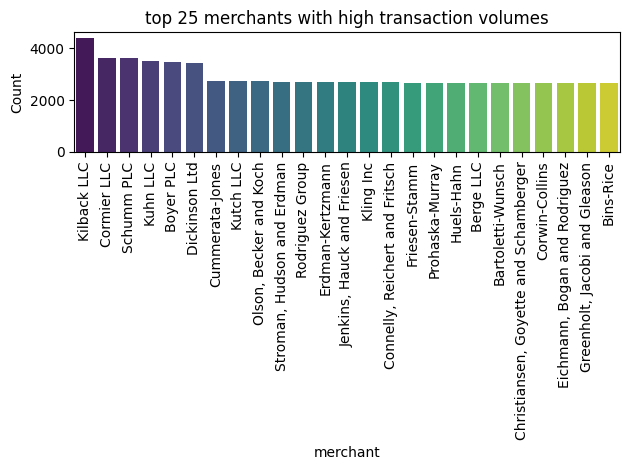

In [74]:

# Create the plot
plot = sns.countplot(x='merchant', data=data, order=high_trans_merchants, palette='viridis')

# Customize labels and layout
plt.title('top 25 merchants with high transaction volumes')
plt.xlabel('merchant')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [75]:
#constructing the merchant-transaction count distribution
data_merchant = data[['merchant','trans_num']].groupby(['merchant']).count().reset_index()
data_merchant.columns = ['merchant', 'merchant_count']

#creating the zip-fraud distribution
data_fraud_merchant = data[['merchant', 'trans_num', 'is_fraud']].groupby(['merchant','is_fraud']).count().reset_index()
data_fraud_merchant.columns = ['merchant', 'is_fraud', 'Transaction count']

data_fraud_merchant = data_fraud_merchant.merge(data_merchant[['merchant', 'merchant_count']], how='inner', on='merchant')

data_fraud_merchant['Transaction percentage'] = (data_fraud_merchant['Transaction count']/data_fraud_merchant['merchant_count'])*100

#viewing the top 20 merchant with high fraudulent transaction volumes
data_fraud_merchant[data_fraud_merchant['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(25)

,merchant,is_fraud,Transaction count,merchant_count,Transaction percentage
672,Kozey-Boehm,1,48,1866,2.572347
489,"Herman, Treutel and Dickens",1,33,1300,2.538462
606,Kerluke-Abshire,1,41,1838,2.230686
159,Brown PLC,1,26,1176,2.210884
400,Goyette Inc,1,42,1943,2.161606
1220,Terry-Huel,1,43,1996,2.154309
562,Jast Ltd,1,42,1953,2.150538
1100,"Schmeler, Bashirian and Price",1,41,1968,2.083333
145,Boyer-Reichert,1,38,1908,1.991614
742,"Langworth, Boehm and Gulgowski",1,39,1969,1.980701


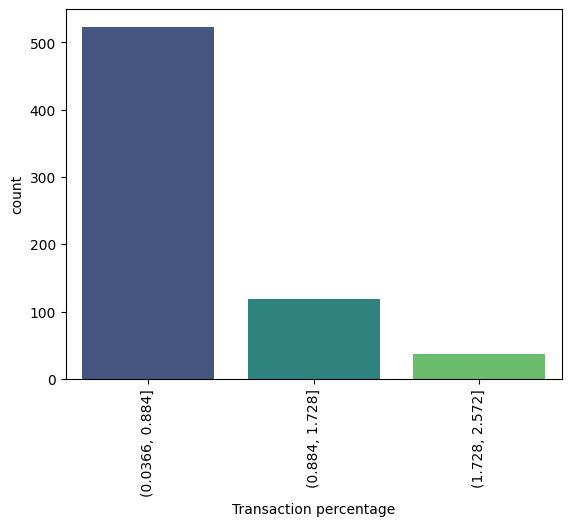

In [76]:
#plotting the fraudulent transactions percentage by binning
plot = sns.countplot(x=pd.cut(data_fraud_merchant[data_fraud_merchant.is_fraud == 1]['Transaction percentage'], bins = 3), palette='viridis')
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)
plt.show()

In [77]:
#number of merchants with more than one percent fraudulent transactions
len(data_fraud_merchant.loc[(data_fraud_merchant.is_fraud == 1) & (data_fraud_merchant['Transaction percentage'] >= 1)].merchant)

145

In [78]:
#number of merchants with more than one percent fraudulent transactions
data_fraud_merchant.loc[(data_fraud_merchant.is_fraud == 1) & (data_fraud_merchant['Transaction percentage'] >= 2)].merchant

159                         Brown PLC
400                       Goyette Inc
489       Herman, Treutel and Dickens
562                          Jast Ltd
606                   Kerluke-Abshire
672                       Kozey-Boehm
1100    Schmeler, Bashirian and Price
1220                       Terry-Huel
Name: merchant, dtype: object

# Observation ('merchant' feature):
- from the above plots and dataframes created, it can be observed that aboout 140 merchants have more than 1% transactions associated with them as fraudulent transactions.
- Also, the merchants fraud_Brown PLC; fraud_Goyette Inc; fraud_Herman; Treutel and Dickens; fraud_Jast Ltd; fraud_Kerluke-Abshire; fraud_Kozey-Boehm; fraud_Schmeler, Bashirian and Price; fraud_Terry-Huel are top merchants with highest number of fraudulent transactions.
# Inference:
- The aforementioned merchants can be checked for fraudulent practices.
- They also can be alerted about the fraudulent practices happening and be educated about how to avoid them.

# Exploring 'Distances' Feature:
calculate transaction distance between user and merchant

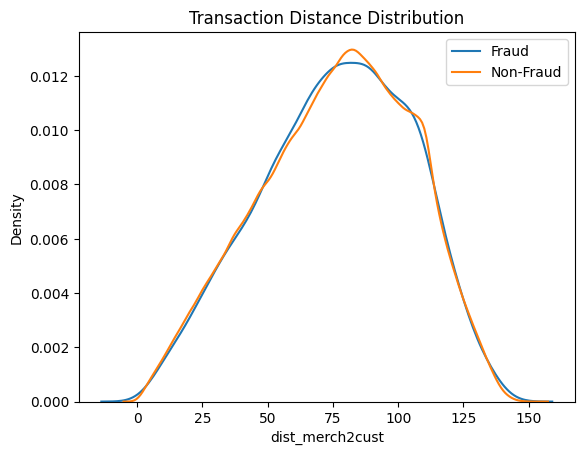

In [79]:
sns.kdeplot(data[data['is_fraud']==1]['dist_merch2cust'], label='Fraud')
sns.kdeplot(data[data['is_fraud']==0]['dist_merch2cust'], label='Non-Fraud')
plt.legend()
plt.title('Transaction Distance Distribution')
plt.show()

- We observed that fraudulent and non-fraudulent transactions have nearly identical distance distributions, indicating distance alone isn’t a strong fraud predictor.

- Most transactions — both legit and fraudulent — occur within 75 to 100 Km

#######################################

# features encoding 

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 28 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   cc_num                  1296675 non-null  int64         
 1   merchant                1296675 non-null  object        
 2   category                1296675 non-null  object        
 3   amt                     1296675 non-null  float64       
 4   street                  1296675 non-null  object        
 5   city                    1296675 non-null  object        
 6   state                   1296675 non-null  object        
 7   zip                     1296675 non-null  int64         
 8   lat                     1296675 non-null  float64       
 9   long                    1296675 non-null  float64       
 10  city_pop                1296675 non-null  int64         
 11  job                     1296675 non-null  object        
 12  trans_num     

In [81]:
#one-hot encoding the category variable
category_onehot = pd.get_dummies(data.category, prefix='category', drop_first=True)
#one-hot encoding the day_of_week variable
day_of_week_onehot = pd.get_dummies(data.trans_day, prefix='day', drop_first=True)
#one-hot encoding the age variable
age_onehot = pd.get_dummies(data.age, prefix='age', drop_first=True)

In [82]:
data = pd.concat([data, category_onehot,day_of_week_onehot,age_onehot], axis=1)

data.head()

,cc_num,merchant,category,amt,street,city,state,zip,lat,long,...,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,age_46-60,age_61-75,age_< 30,age_> 75
0,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,...,False,False,False,False,True,False,False,False,False,False
1,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,...,False,False,False,False,True,False,False,False,False,False
2,38859492057661,Lind-Buckridge,entertainment,220.11,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,...,False,False,False,False,True,False,True,False,False,False
3,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,...,False,False,False,False,True,False,True,False,False,False
4,375534208663984,Keeling-Crist,misc_pos,41.96,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,...,False,False,False,False,True,False,False,False,False,False


In [83]:
data.drop([ 'cc_num', 'trans_num'], axis=1, inplace=True)

In [84]:
data.drop(['merchant','street','city','state','job',
          'category','trans_day',
          'age'],axis=1, inplace=True)
data.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
       'is_fraud', 'is_holiday', 'is_5multiple', 'is_lt2', 'is_near2500',
       'is_whole_num', 'is_595ending', 'is_high_risk_merch_cat',
       'dist_merch2cust', 'trans_hour', 'trans_date', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'day_Monday',
       'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday',
       'day_Wednesday', 'age_46-60', 'age_61-75', 'age_< 30', 'age_> 75'],
      dtype='object')

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 41 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   amt                      1296675 non-null  float64       
 1   zip                      1296675 non-null  int64         
 2   lat                      1296675 non-null  float64       
 3   long                     1296675 non-null  float64       
 4   city_pop                 1296675 non-null  int64         
 5   merch_lat                1296675 non-null  float64       
 6   merch_long               1296675 non-null  float64       
 7   is_fraud                 1296675 non-null  int64         
 8   is_holiday               1296675 non-null  bool          
 9   is_5multiple             1296675 non-null  bool          
 10  is_lt2                   1296675 non-null  bool          
 11  is_near2500              1296675 non-null  bool          
 12  

In [86]:
date_column = data['trans_date']
data.drop(['trans_date'], axis=1, inplace=True)

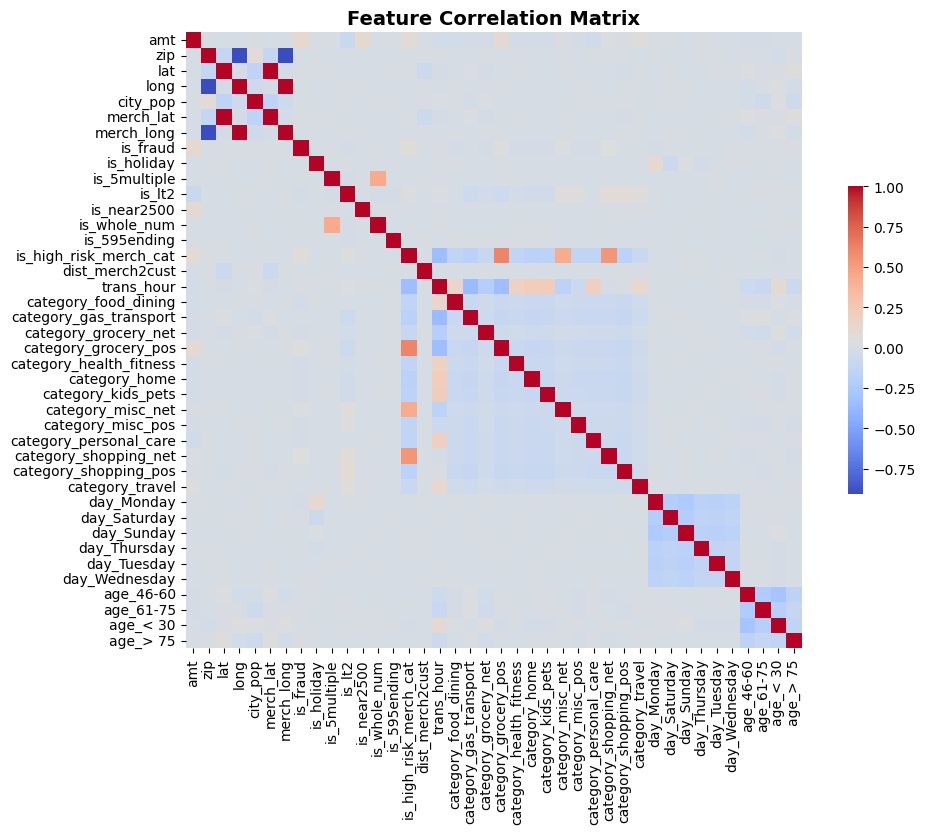

In [87]:
plt.figure(figsize=(12, 8))
df_random_under_corr = data.corr()
sns.heatmap(df_random_under_corr, annot=False, cmap='coolwarm', square=True, cbar_kws={"shrink": .5})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

In [88]:
#function to return highly correlated column above a threshold
def correlation(dataset, threshold):
    col_corr = set() # This set stores the highly correlated columns
    corr_matrix = dataset.corr() #correlation matrix
    #traversing the correlation matrix
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j] > threshold:
                colname = corr_matrix.columns[i] #selecting columns above threshold
                col_corr.add(colname) #adding columns to set
    return col_corr

In [89]:
#let us get the features with correlation above 85%
corr_features = correlation(data,0.85)
corr_features

{'merch_lat', 'merch_long'}

In [90]:
data.drop(['zip', 'lat', 'long', 'city_pop', 'merch_lat','merch_long'],
            axis=1, inplace=True)

In [91]:
X = data.drop(['is_fraud'],axis=1)
y = data.is_fraud


In [92]:
X = X.astype('float32') 

In [93]:
#scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [94]:
from sklearn.model_selection import train_test_split

# Step 1: Split into 70% train and 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Split temp into 15% val and 15% test (i.e., 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [95]:
# Initialize and train the Random Forest classifier
RF = RandomForestClassifier(n_estimators=100, random_state=0)
RF.fit(X_train, y_train)

predict_RF = RF.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_RF))
RF_accuracy = accuracy_score(predict_RF, y_test)
print('Random Forest model accuracy is: {:.2f}%'.format(RF_accuracy * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.93      0.68      0.79      1126

    accuracy                           1.00    194502
   macro avg       0.96      0.84      0.89    194502
weighted avg       1.00      1.00      1.00    194502

Random Forest model accuracy is: 99.79%


In [96]:
# Initialize and train the Random Forest classifier
RF = RandomForestClassifier(n_estimators=100, random_state=0, class_weight='balanced')
RF.fit(X_train, y_train)

predict_RF = RF.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_RF))
RF_accuracy = accuracy_score(predict_RF, y_test)
print('Random Forest model accuracy is: {:.2f}%'.format(RF_accuracy * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.91      0.68      0.78      1126

    accuracy                           1.00    194502
   macro avg       0.95      0.84      0.89    194502
weighted avg       1.00      1.00      1.00    194502

Random Forest model accuracy is: 99.78%


In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
X_train_val = np.concatenate((X_train, X_val), axis=0)
y_train_val = np.concatenate((y_train, y_val), axis=0)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
# Step 5: Grid search on train+val
rf_base = RandomForestClassifier(random_state=0)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=3, scoring='f1', verbose=2, n_jobs=1)
grid_search.fit(X_train_val, y_train_val)

# Step 6: Evaluate best model on test set
best_rf = grid_search.best_estimator_
predict_RF = best_rf.predict(X_test)

print(classification_report(y_test, predict_RF))
RF_accuracy = accuracy_score(y_test, predict_RF)
print('Tuned Random Forest model accuracy: {:.2f}%'.format(RF_accuracy * 100))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  37.0s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.1min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.2min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 8.3min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 3.9min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time= 3.5min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, m

In [98]:
from xgboost import XGBClassifier

XGB = XGBClassifier(random_state=0)
XGB.fit(X_train, y_train)

# Make predictions on the test set
predict_XGB = XGB.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_XGB))
XGB_accuracy = accuracy_score(predict_XGB, y_test)
print('XGBoost model accuracy is: {:.2f}%'.format(XGB_accuracy * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.91      0.72      0.80      1126

    accuracy                           1.00    194502
   macro avg       0.95      0.86      0.90    194502
weighted avg       1.00      1.00      1.00    194502

XGBoost model accuracy is: 99.79%


In [99]:
from xgboost import XGBClassifier
neg, pos = np.bincount(y_train)
scale_weight = neg / pos

XGB = XGBClassifier(random_state=0, scale_pos_weight=scale_weight)
XGB.fit(X_train, y_train)

# Make predictions on the test set
predict_XGB = XGB.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_XGB))
XGB_accuracy = accuracy_score(predict_XGB, y_test)
print('XGBoost model accuracy is: {:.2f}%'.format(XGB_accuracy * 100))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    193376
           1       0.28      0.94      0.43      1126

    accuracy                           0.99    194502
   macro avg       0.64      0.97      0.71    194502
weighted avg       1.00      0.99      0.99    194502

XGBoost model accuracy is: 98.53%


In [100]:
from lightgbm import LGBMClassifier


# Initialize and train the LightGBM classifier
LGB_model = LGBMClassifier(n_estimators=100, random_state=0)
LGB_model.fit(X_train, y_train)

# Make predictions on the test set
predict_LGB = LGB_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_LGB))
LGB_accuracy = accuracy_score(y_test, predict_LGB)
print('LightGBM model accuracy is: {:.2f}%'.format(LGB_accuracy * 100))

[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.76      0.70      0.73      1126

    accuracy                           1.00    194502
   macro avg       0.88      0.85      0.86    194502
weighted avg       1.00      1.00      1.00    194502

LightGBM model accuracy is: 99.70%


In [101]:
from lightgbm import LGBMClassifier


# Initialize and train the LightGBM classifier
LGB_model = LGBMClassifier(n_estimators=100, random_state=0, class_weight='balanced')
LGB_model.fit(X_train, y_train)

# Make predictions on the test set
predict_LGB = LGB_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_LGB))
LGB_accuracy = accuracy_score(y_test, predict_LGB)
print('LightGBM model accuracy is: {:.2f}%'.format(LGB_accuracy * 100))

[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 625
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    193376
           1       0.19      0.97      0.32      1126

    accuracy                           0.98    194502
   macro avg       0.60      0.98      0.66    194502
weighted avg       1.00      0.98      0.98    194502

LightGBM model accuracy is: 97.63%
